# UNH Aquafort Buoy Station - Initial Data Exploration

**Date:** October 31, 2025  
**Data Source:** UNH Aquafort Buoy Station (Campbell Scientific TOA5 Format)

## Overview

This notebook performs an initial exploratory data analysis (EDA) of two datasets from the UNH Aquafort buoy station:

1. **EXO2SumData** - Water quality monitoring data (EXO2 sonde)
2. **ZCelEngData** - Current profiler and engineering data (ZCell ADCP)

Both files are in Campbell Scientific TOA5 format, a specialized CSV format used by Campbell Scientific data loggers.

## 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

# Import from our imta_analytics package
from imta_analytics.data import load_toa5_file
from imta_analytics.notebook_utils import display_info, display_success, display_warning, format_dict_as_list
from imta_analytics.analysis import (
    plot_timeseries_grid,
    plot_availability_timeline,
    plot_correlation_heatmap,
    plot_current_profile,
)

warnings.filterwarnings('ignore')

# Set style preferences - use seaborn styling
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

display_success("Libraries imported successfully<br>Using imta_analytics package v0.1.0")

## 2. Data Loading

### Understanding TOA5 Format

Campbell Scientific TOA5 files have a specific structure:
- **Line 1:** File format metadata (station name, logger model, etc.)
- **Line 2:** Column headers
- **Line 3:** Units for each column
- **Line 4:** Sampling information (e.g., "Smp", "Avg" - this confuses pandas type inference!)
- **Line 5+:** Actual data

### Campbell Scientific NaN Sentinel Values

Campbell Scientific dataloggers use **data-type-specific sentinel values** instead of IEEE NaN:
- **FP2 (Float Point 2)**: Uses `-7999` to represent NaN (most common for sensor data)
- **Long Integer**: Uses `-2147483648` (most negative 32-bit integer)
- **Overrange values**: ±6999, ±7999 may indicate measurement overrange

These sentinel values occur when:
1. Input signals exceed voltage range
2. Invalid SDI-12 command sent to sensor
3. SDI-12 sensor does not respond or aborts
4. Measurement overrange

The `load_toa5_file()` function from the `imta_analytics` package handles this format correctly by:
1. Skipping all 4 header lines to avoid type inference issues
2. Explicitly converting all columns (except TIMESTAMP) to numeric types
3. **Converting Campbell Scientific sentinel values (-7999, -2147483648, ±6999, ±7999) to proper NaN**
4. Parsing TIMESTAMP as datetime objects
5. Returning metadata and units separately for reference

*Reference: Campbell Scientific CR1000X Product Manual, Section 14.2 "Understanding NAN"*

In [2]:
# Define file paths
DATA_DIR = Path('../data/aquafort-buoy-station')
EXO2_FILE = DATA_DIR / 'UNH-G2000B_EXO2SumData.dat'
ZCEL_FILE = DATA_DIR / 'UNH-G2000B_ZCelEngData.dat'

display_info(f"""
<strong>Data Directory:</strong> {DATA_DIR.absolute()}<br>
<strong>EXO2 file exists:</strong> {EXO2_FILE.exists()}<br>
<strong>ZCel file exists:</strong> {ZCEL_FILE.exists()}
""")

### Load Data Using imta_analytics Package

We're now using the `load_toa5_file()` function from the `imta_analytics.data` module. This function:
- Returns a tuple of (DataFrame, metadata dict, units list)
- Handles the tricky TOA5 format with proper type inference
- Explicitly converts all columns to appropriate types (numeric or datetime)
- **Automatically converts Campbell Scientific NaN sentinels to proper NaN**
- Returns metadata about the logger and station
- Returns units for each column

This makes our code cleaner and reusable across multiple notebooks and eventually in a web application.

See `imta_analytics/data/README.md` for comprehensive documentation on Campbell Scientific sentinel values.

### Load EXO2 Water Quality Data

In [3]:
# Load EXO2 data
exo2_df, exo2_metadata, exo2_units = load_toa5_file(EXO2_FILE)

metadata_items = format_dict_as_list(exo2_metadata)

display_info(f"""
<strong>EXO2 Metadata:</strong>
{metadata_items}
<strong>Dataset shape:</strong> {exo2_df.shape}<br>
<strong>Date range:</strong> {exo2_df['TIMESTAMP'].min()} to {exo2_df['TIMESTAMP'].max()}
""")

In [4]:
# Display column information with units
columns_list = "<br>".join([f"{i+1:2d}. <strong>{col}</strong> [{unit}]" 
                            for i, (col, unit) in enumerate(zip(exo2_df.columns, exo2_units))])

display_info(f"""
<strong>EXO2 Columns and Units:</strong><br>
{columns_list}
""")

In [5]:
# Display first few rows
display_info("<strong>First 5 rows of EXO2 data:</strong>")
exo2_df.head().T

,0,1,2,3,4
TIMESTAMP,2024-12-20 14:32:10,2024-12-20 14:47:10,2024-12-20 15:02:10,2024-12-20 15:32:10,2024-12-20 15:32:10
RECORD,31964,31965,31966,31967,31967
EXO2Date,122024.000,122024.000,122024.000,122024.000,122024.000
EXO2Time,93142.000,94642.000,100142.000,103142.000,103142.000
EXO2pH,8.030,8.030,8.030,8.050,8.050
EXO2pHmV,-78.250,-78.250,-78.260,-78.870,-78.870
EXO2fDOM,9.560,9.160,10.170,13.710,13.710
EXO2Temp,7.069,7.113,6.979,6.543,6.543
EXO2spCond,48.888,49.023,48.611,47.294,47.294
EXO2Salinity,31.500,31.600,31.290,30.310,30.310


### Load ZCell Current Profiler Data

In [6]:
# Load ZCel data
zcel_df, zcel_metadata, zcel_units = load_toa5_file(ZCEL_FILE)

metadata_items = format_dict_as_list(zcel_metadata)

display_info(f"""
<strong>ZCell Metadata:</strong>
{metadata_items}
<strong>Dataset shape:</strong> {zcel_df.shape}<br>
<strong>Date range:</strong> {zcel_df['TIMESTAMP'].min()} to {zcel_df['TIMESTAMP'].max()}
""")

In [7]:
# Display column information (first 30 columns)
columns_list = "<br>".join([f"{i+1:2d}. <strong>{col}</strong> [{unit}]" 
                            for i, (col, unit) in enumerate(zip(zcel_df.columns[:30], zcel_units[:30]))])

display_info(f"""
<strong>ZCell Columns and Units (first 30):</strong><br>
{columns_list}<br>
<br>... and {len(zcel_df.columns) - 30} more columns
""")

In [8]:
# Display first few rows (limited columns for readability)
display_info("<strong>First 5 rows of ZCell data (selected columns):</strong>")
display_cols = ['TIMESTAMP', 'RECORD', 'batt_volt', 'PTemp', 'ZCel_Batt', 
                'ZCel_Hdng', 'ZCel_Pitch', 'ZCel_Roll', 'ZCel_Press', 'ZCel_WTmp']
#zcel_df[display_cols].head().T
zcel_df.head().T

,0,1,2,3,4
TIMESTAMP,2024-12-20 00:28:05,2024-12-20 00:38:05,2024-12-20 00:48:05,2024-12-20 00:58:05,2024-12-20 01:08:05
RECORD,32562,32563,32564,32565,32566
batt_volt,13.000,12.990,12.990,12.980,12.980
PTemp,4.411,4.272,4.138,3.960,3.816
ZCelRecLen,406,406,406,406,406
ZCelDateStr,NaN,NaN,NaN,NaN,NaN
ZCel_ErrCd,0.000,0.000,0.000,0.000,0.000
ZCel_StatCd,49.000,49.000,49.000,49.000,49.000
ZCel_Batt,12.100,12.000,12.000,12.000,12.100
ZCel_SpdSnd,1482.000,1481.000,1481.000,1481.000,1481.000


## 3. Data Quality Assessment

### 3.1 EXO2 Water Quality Data

In [9]:
# Check for missing values
missing_exo2 = exo2_df.isnull().sum()
missing_exo2_pct = (missing_exo2 / len(exo2_df)) * 100

display_info("<strong>Missing Values in EXO2 Data:</strong>")
missing_summary = pd.DataFrame({
    'Missing Count': missing_exo2,
    'Percentage': missing_exo2_pct
}).sort_values('Missing Count', ascending=False)

missing_summary[missing_summary['Missing Count'] > 0]

,Missing Count,Percentage
EXO2spCond,1245,4.593
EXO2Salinity,1245,4.593
EXO2pHmV,1245,4.593
EXO2pH,1245,4.593
EXO2DomgpL,1245,4.593
EXO2Depth,1245,4.593
EXO2BGAPE,1245,4.593
EXO2ChlorugpL,1245,4.593
EXO2Chlor,147,0.542
EXO2Turb,147,0.542


In [10]:
# Check for duplicate timestamps
duplicate_timestamps = exo2_df['TIMESTAMP'].duplicated().sum()

if duplicate_timestamps > 0:
    display_warning(f"<strong>Duplicate timestamps in EXO2:</strong> {duplicate_timestamps}")
    display(exo2_df[exo2_df['TIMESTAMP'].duplicated(keep=False)][['TIMESTAMP','RECORD']].groupby('TIMESTAMP').count().sort_values(by='RECORD', ascending=False).head())
else:
    display_success(f"<strong>No duplicate timestamps found in EXO2 data</strong>")

,RECORD
TIMESTAMP,
2024-12-20 16:47:10,3
2024-12-20 15:32:10,2
2024-12-20 15:47:10,2
2025-01-17 01:17:10,2
2025-01-26 14:32:10,2


In [11]:
# Descriptive statistics for key water quality parameters
key_params = ['EXO2DO', 'EXO2pH', 'EXO2Temp', 'EXO2Salinity', 'EXO2DO', 'EXO2Chlor', 'EXO2Turb', 'EXO2Depth']
display_info("<strong>Descriptive Statistics - Key Water Quality Parameters:</strong>")
exo2_df[key_params].describe()

,EXO2DO,EXO2pH,EXO2Temp,EXO2Salinity,EXO2DO,EXO2Chlor,EXO2Turb,EXO2Depth
count,26962.000,25864.000,26962.000,25864.000,26962.000,26962.000,26962.000,25864.000
mean,5943.299,8.062,5852.654,30.424,5943.299,5844.144,537.985,0.361
std,28303.383,0.071,28322.085,2.862,28303.383,28323.841,2641.418,0.846
min,78.930,7.810,0.326,-86.480,78.930,-0.050,0.170,-86.480
25%,100.190,8.020,4.557,29.740,100.190,0.200,0.850,0.323
50%,104.055,8.070,9.954,31.250,104.055,0.340,1.330,0.379
75%,108.600,8.110,14.898,31.900,108.600,0.570,3.730,0.434
max,193039.000,8.320,193039.000,33.140,193039.000,193039.000,91625.000,0.594


### 3.2 ZCell Current Profiler Data

In [12]:
# Check for missing values in engineering parameters
eng_params = ['batt_volt', 'PTemp', 'ZCel_Batt', 'ZCel_Hdng', 'ZCel_Pitch', 
              'ZCel_Roll', 'ZCel_Press', 'ZCel_WTmp']

missing_zcel = zcel_df[eng_params].isnull().sum()
missing_zcel_pct = (missing_zcel / len(zcel_df)) * 100

display_info("<strong>Missing Values in ZCell Engineering Data:</strong>")
pd.DataFrame({
    'Missing Count': missing_zcel,
    'Percentage': missing_zcel_pct
}).sort_values('Missing Count', ascending=False)

,Missing Count,Percentage
ZCel_Hdng,14623,24.758
ZCel_Batt,14623,24.758
ZCel_Roll,14623,24.758
ZCel_Pitch,14623,24.758
ZCel_Press,14623,24.758
ZCel_WTmp,14623,24.758
batt_volt,0,0.000
PTemp,0,0.000


In [13]:
# Descriptive statistics for engineering parameters
display_info("<strong>Descriptive Statistics - Engineering Parameters:</strong>")
zcel_df[eng_params].describe().T

,count,mean,std,min,25%,50%,75%,max
batt_volt,59064.000,13.357,0.445,12.250,12.920,13.490,13.660,14.950
PTemp,59064.000,8.980,7.634,-7.103,4.050,6.780,15.830,32.410
ZCel_Batt,44441.000,12.005,1.094,8.600,11.900,12.100,12.800,13.500
ZCel_Hdng,44441.000,212.225,79.895,0.000,164.200,214.600,292.700,359.800
ZCel_Pitch,44441.000,1.210,1.199,-10.200,0.600,1.400,1.700,9.800
ZCel_Roll,44441.000,1.835,1.143,-10.900,1.300,1.700,2.200,11.100
ZCel_Press,44441.000,0.522,0.241,0.000,0.342,0.425,0.797,1.041
ZCel_WTmp,44441.000,8.522,5.514,1.650,3.350,6.680,14.050,19.400


In [14]:
# Analyze current profile structure
# Find all depth and current speed columns
depth_cols = [col for col in zcel_df.columns if col.startswith('ZCelDpth')]
speed_cols = [col for col in zcel_df.columns if col.startswith('CurrSpd')]
dir_cols = [col for col in zcel_df.columns if col.startswith('CurrDir')]

info_lines = [
    f"<strong>Depth bins:</strong> {len(depth_cols)}",
    f"<strong>Speed measurements:</strong> {len(speed_cols)}",
    f"<strong>Direction measurements:</strong> {len(dir_cols)}"
]

if len(depth_cols) > 0:
    first_depths = zcel_df[depth_cols].iloc[0]
    info_lines.append(f"<br><strong>Depth range (first record):</strong>")
    info_lines.append(f"&nbsp;&nbsp;Surface: {first_depths.iloc[0]} m")
    info_lines.append(f"&nbsp;&nbsp;Bottom: {first_depths.iloc[-1]} m")

display_info(f"""
<strong>Current Profile Structure:</strong><br>
{"<br>".join(info_lines)}
""")

## 4. Temporal Analysis

### 4.1 Time Series Coverage

In [15]:
# Analyze sampling frequency
exo2_df['time_diff'] = exo2_df['TIMESTAMP'].diff()
zcel_df['time_diff'] = zcel_df['TIMESTAMP'].diff()

display_info(f"""
<strong>Sampling Frequency Analysis:</strong><br><br>
<strong>EXO2 Data:</strong><br>
&nbsp;&nbsp;Most common interval: {exo2_df['time_diff'].mode().iloc[0]}<br>
&nbsp;&nbsp;Mean interval: {exo2_df['time_diff'].mean()}<br>
&nbsp;&nbsp;Total duration: {exo2_df['TIMESTAMP'].max() - exo2_df['TIMESTAMP'].min()}<br>
&nbsp;&nbsp;Number of records: {len(exo2_df):,}<br>
<br>
<strong>ZCell Data:</strong><br>
&nbsp;&nbsp;Most common interval: {zcel_df['time_diff'].mode().iloc[0]}<br>
&nbsp;&nbsp;Mean interval: {zcel_df['time_diff'].mean()}<br>
&nbsp;&nbsp;Total duration: {zcel_df['TIMESTAMP'].max() - zcel_df['TIMESTAMP'].min()}<br>
&nbsp;&nbsp;Number of records: {len(zcel_df):,}
""")

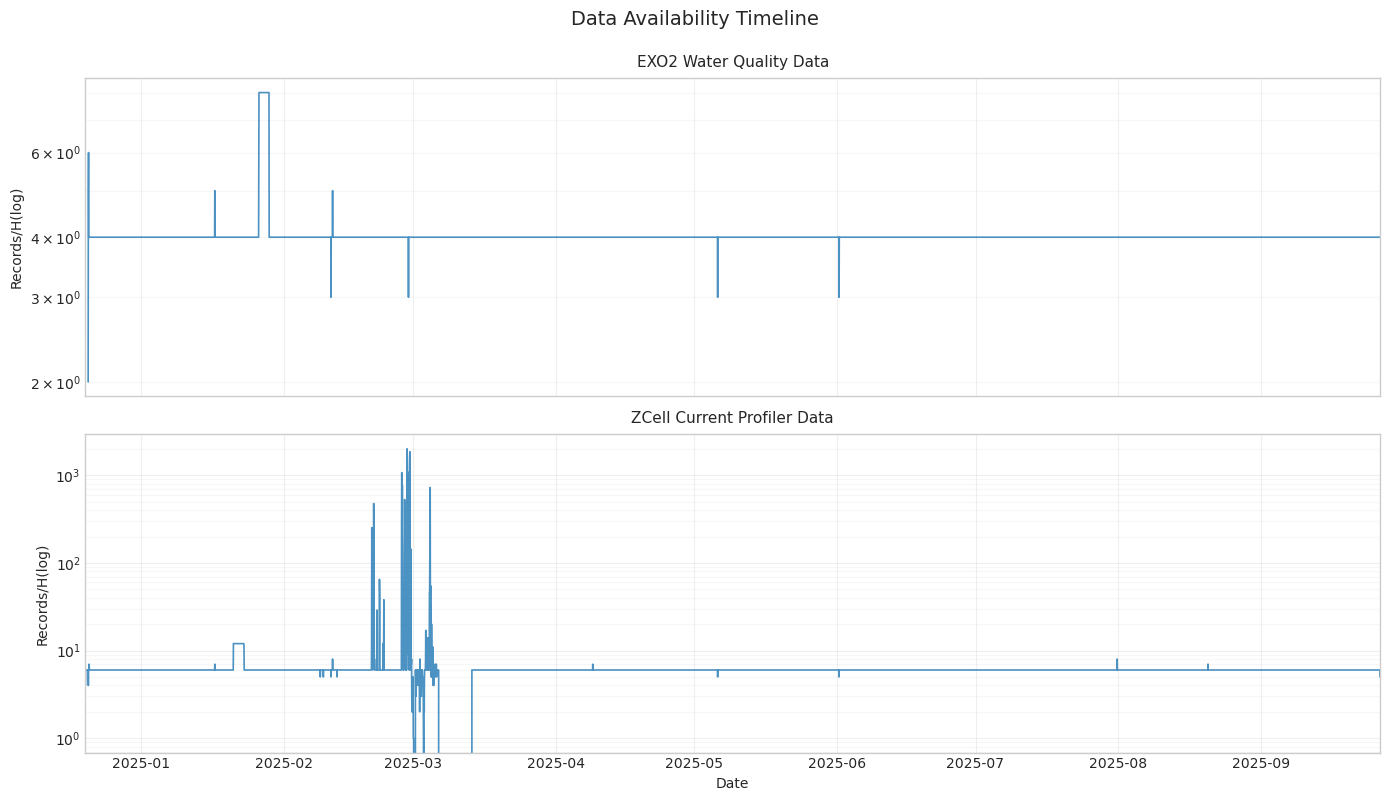

In [16]:
# Visualize data availability
fig, axes = plot_availability_timeline(
    dfs=[exo2_df, zcel_df],
    labels=['EXO2 Water Quality Data', 'ZCell Current Profiler Data'],
    timestamp_col='TIMESTAMP',
    record_col='RECORD',
    resample_freq='H',
    title='Data Availability Timeline',
    figsize=(14, 8)
)
plt.show()

### 4.2 Water Quality Time Series

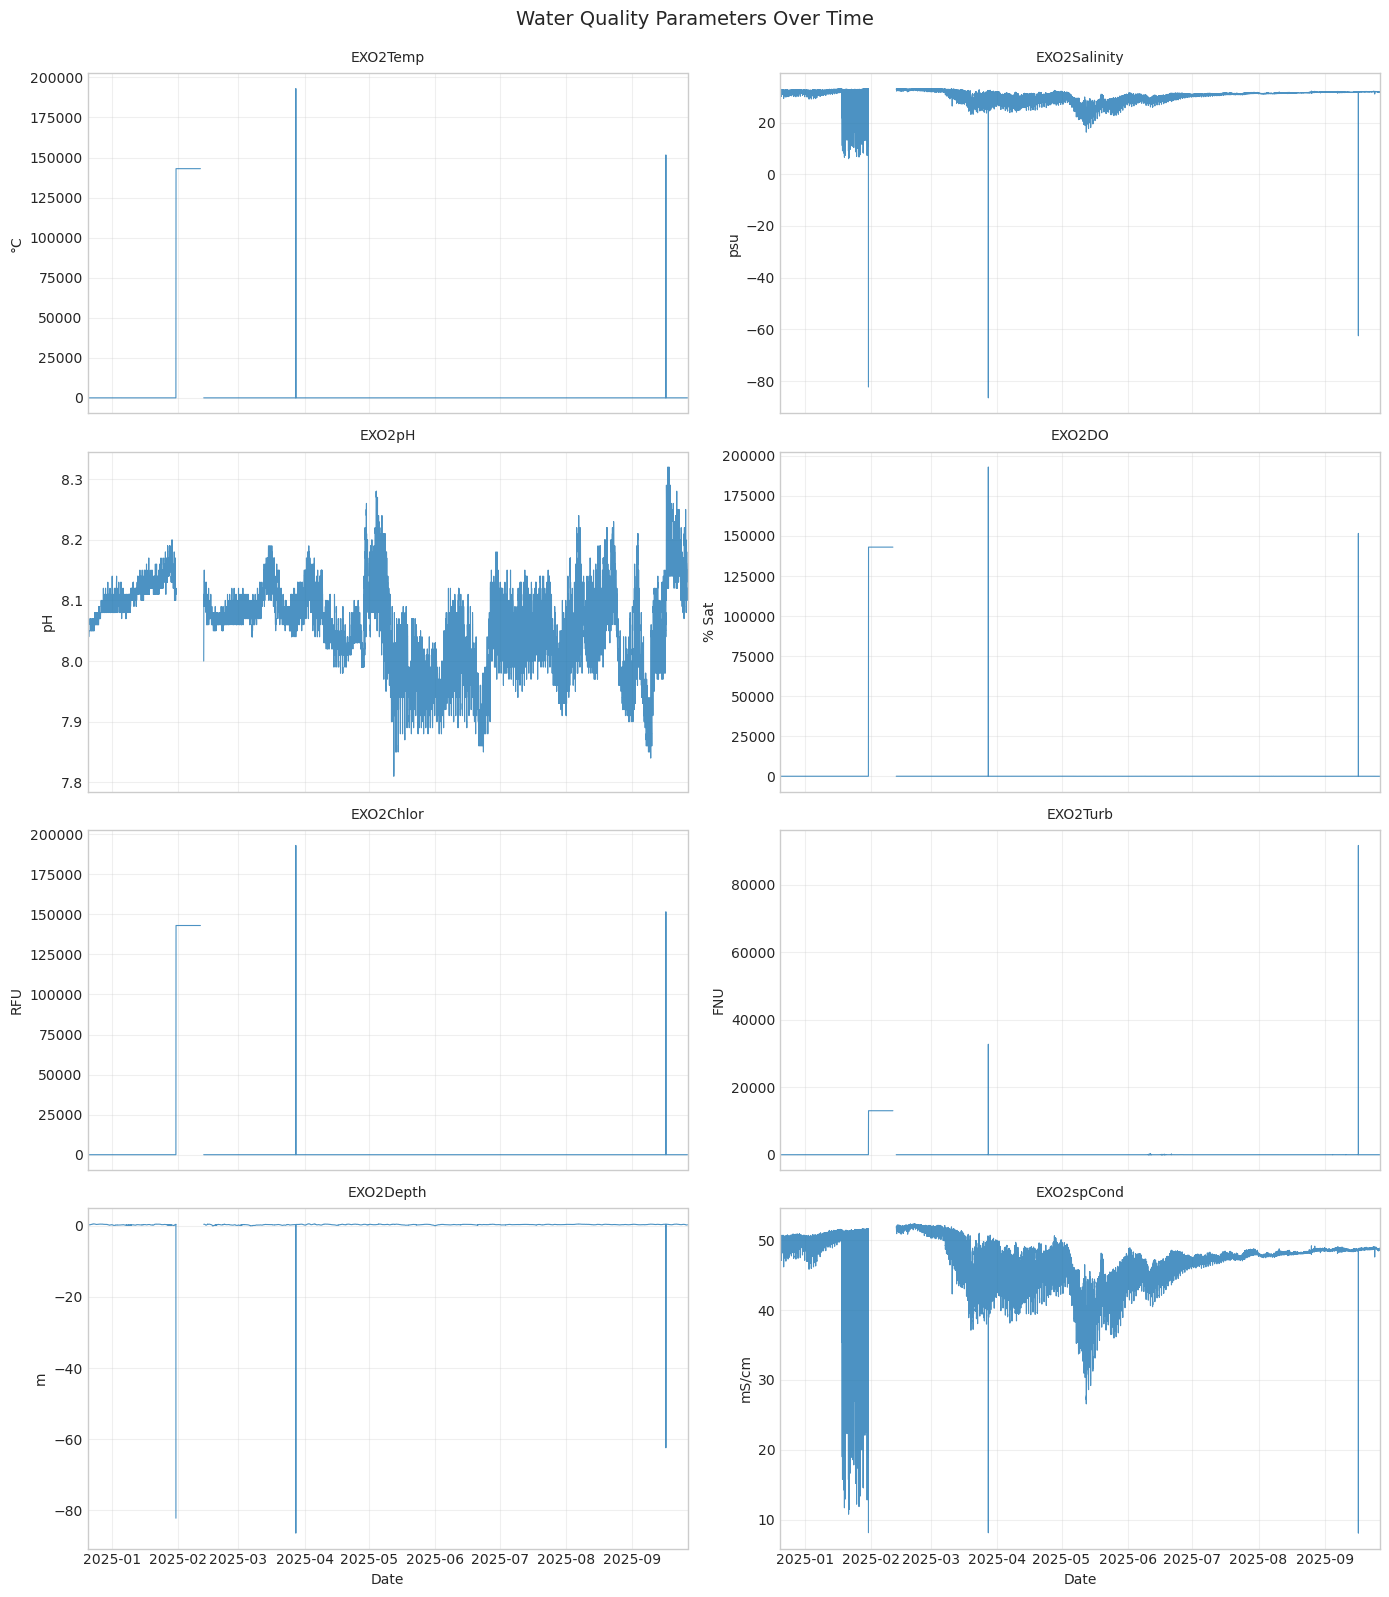

In [17]:
# Create time series plots for key water quality parameters
params = [
    ('EXO2Temp', '°C'),
    ('EXO2Salinity', 'psu'),
    ('EXO2pH', 'pH'),
    ('EXO2DO', '% Sat'),
    ('EXO2Chlor', 'RFU'),
    ('EXO2Turb', 'FNU'),
    ('EXO2Depth', 'm'),
    ('EXO2spCond', 'mS/cm')
]

fig, axes = plot_timeseries_grid(
    df=exo2_df,
    params=params,
    timestamp_col='TIMESTAMP',
    title='Water Quality Parameters Over Time',
    figsize=(14, 16),
    layout=(4, 2)
)
plt.show()

In [18]:
# Let's check for outliers and anomalies in the water quality data
key_params = ['EXO2Temp', 'EXO2Salinity', 'EXO2pH', 'EXO2DO', 
              'EXO2Chlor', 'EXO2Turb', 'EXO2Depth', 'EXO2spCond']

outlier_results = []
for param in key_params:
    data = exo2_df[param].dropna()
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 3 * iqr
    upper_bound = q3 + 3 * iqr
    
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    
    result = f"<strong>{param}:</strong><br>"
    result += f"&nbsp;&nbsp;Range: {data.min():.3f} to {data.max():.3f}<br>"
    result += f"&nbsp;&nbsp;Median: {data.median():.3f}<br>"
    result += f"&nbsp;&nbsp;Q1/Q3: {q1:.3f} / {q3:.3f}<br>"
    result += f"&nbsp;&nbsp;Outliers (>3*IQR): {len(outliers)} values ({len(outliers)/len(data)*100:.2f}%)"
    
    if len(outliers) > 0:
        result += f"<br>&nbsp;&nbsp;Outlier range: {outliers.min():.3f} to {outliers.max():.3f}"
        result += f"<br>&nbsp;&nbsp;Example values: {outliers.head(5).tolist()}"
    
    outlier_results.append(result)

display_info(f"""
<strong>Checking for extreme values / outliers:</strong><br><br>
{"<br><br>".join(outlier_results)}
""")

**Note:** Campbell Scientific NaN sentinel values (-7999, -2147483648, ±6999, ±7999) have been automatically converted to proper NaN by `load_toa5_file()`. The remaining outliers are from sensor drift, calibration issues, or physically impossible measurements that need bounds filtering.

In [19]:
# Create a cleaned version of the data by filtering out physically impossible values
# Note: Campbell Scientific NaN sentinels (-7999, -2147483648, ±6999, ±7999) have already
# been converted to NaN by load_toa5_file(). This step applies physical bounds filtering
# to catch sensor drift, calibration issues, and impossible measurements.

exo2_clean = exo2_df.copy()

# Define reasonable physical bounds for marine water quality parameters
bounds = {
    'EXO2Temp': (-2, 35),        # °C - freezing to tropical
    'EXO2Salinity': (0, 40),     # psu - fresh to hypersaline
    'EXO2pH': (6.5, 9.5),        # pH units
    'EXO2DO': (0, 200),          # % saturation
    'EXO2Chlor': (-1, 100),      # RFU - chlorophyll fluorescence
    'EXO2Turb': (0, 100),        # FNU - turbidity
    'EXO2Depth': (-1, 100),      # m - depth
    'EXO2spCond': (0, 70),       # mS/cm - specific conductivity
    'EXO2DomgpL': (0, 20)        # mg/L - dissolved oxygen
}

filter_results = []
# Apply bounds and replace out-of-range values with NaN
for param, (lower, upper) in bounds.items():
    if param in exo2_clean.columns:
        mask = (exo2_clean[param] < lower) | (exo2_clean[param] > upper)
        invalid_count = mask.sum()
        if invalid_count > 0:
            filter_results.append(f"<strong>{param}:</strong> Removed {invalid_count} invalid values ({invalid_count/len(exo2_clean)*100:.2f}%)")
            exo2_clean.loc[mask, param] = np.nan

# Count NaN from sentinel conversion (already done by load_toa5_file)
sentinel_nan_count = exo2_df[list(bounds.keys())].isna().sum().sum()
bounds_nan_count = exo2_clean[list(bounds.keys())].isna().sum().sum() - sentinel_nan_count

valid_records = exo2_clean[list(bounds.keys())].notna().any(axis=1).sum()

display_success(f"""
<strong>Data Quality Control Applied:</strong><br><br>
<strong>Stage 1 - Campbell Scientific Sentinel Conversion:</strong><br>
&nbsp;&nbsp;Converted {sentinel_nan_count} sentinel values (-7999, -2147483648, ±6999, ±7999) to NaN<br>
<br>
<strong>Stage 2 - Physical Bounds Filtering:</strong><br>
{"<br>".join(filter_results) if filter_results else "&nbsp;&nbsp;No additional values filtered"}<br>
<br>
<strong>Summary:</strong><br>
<strong>Original dataset:</strong> {len(exo2_df):,} records<br>
<strong>Cleaned dataset:</strong> {len(exo2_clean):,} records<br>
<strong>Records with at least one valid measurement:</strong> {valid_records:,}<br>
<strong>Total NaN (sentinels + bounds):</strong> {exo2_clean[list(bounds.keys())].isna().sum().sum():,}
""")

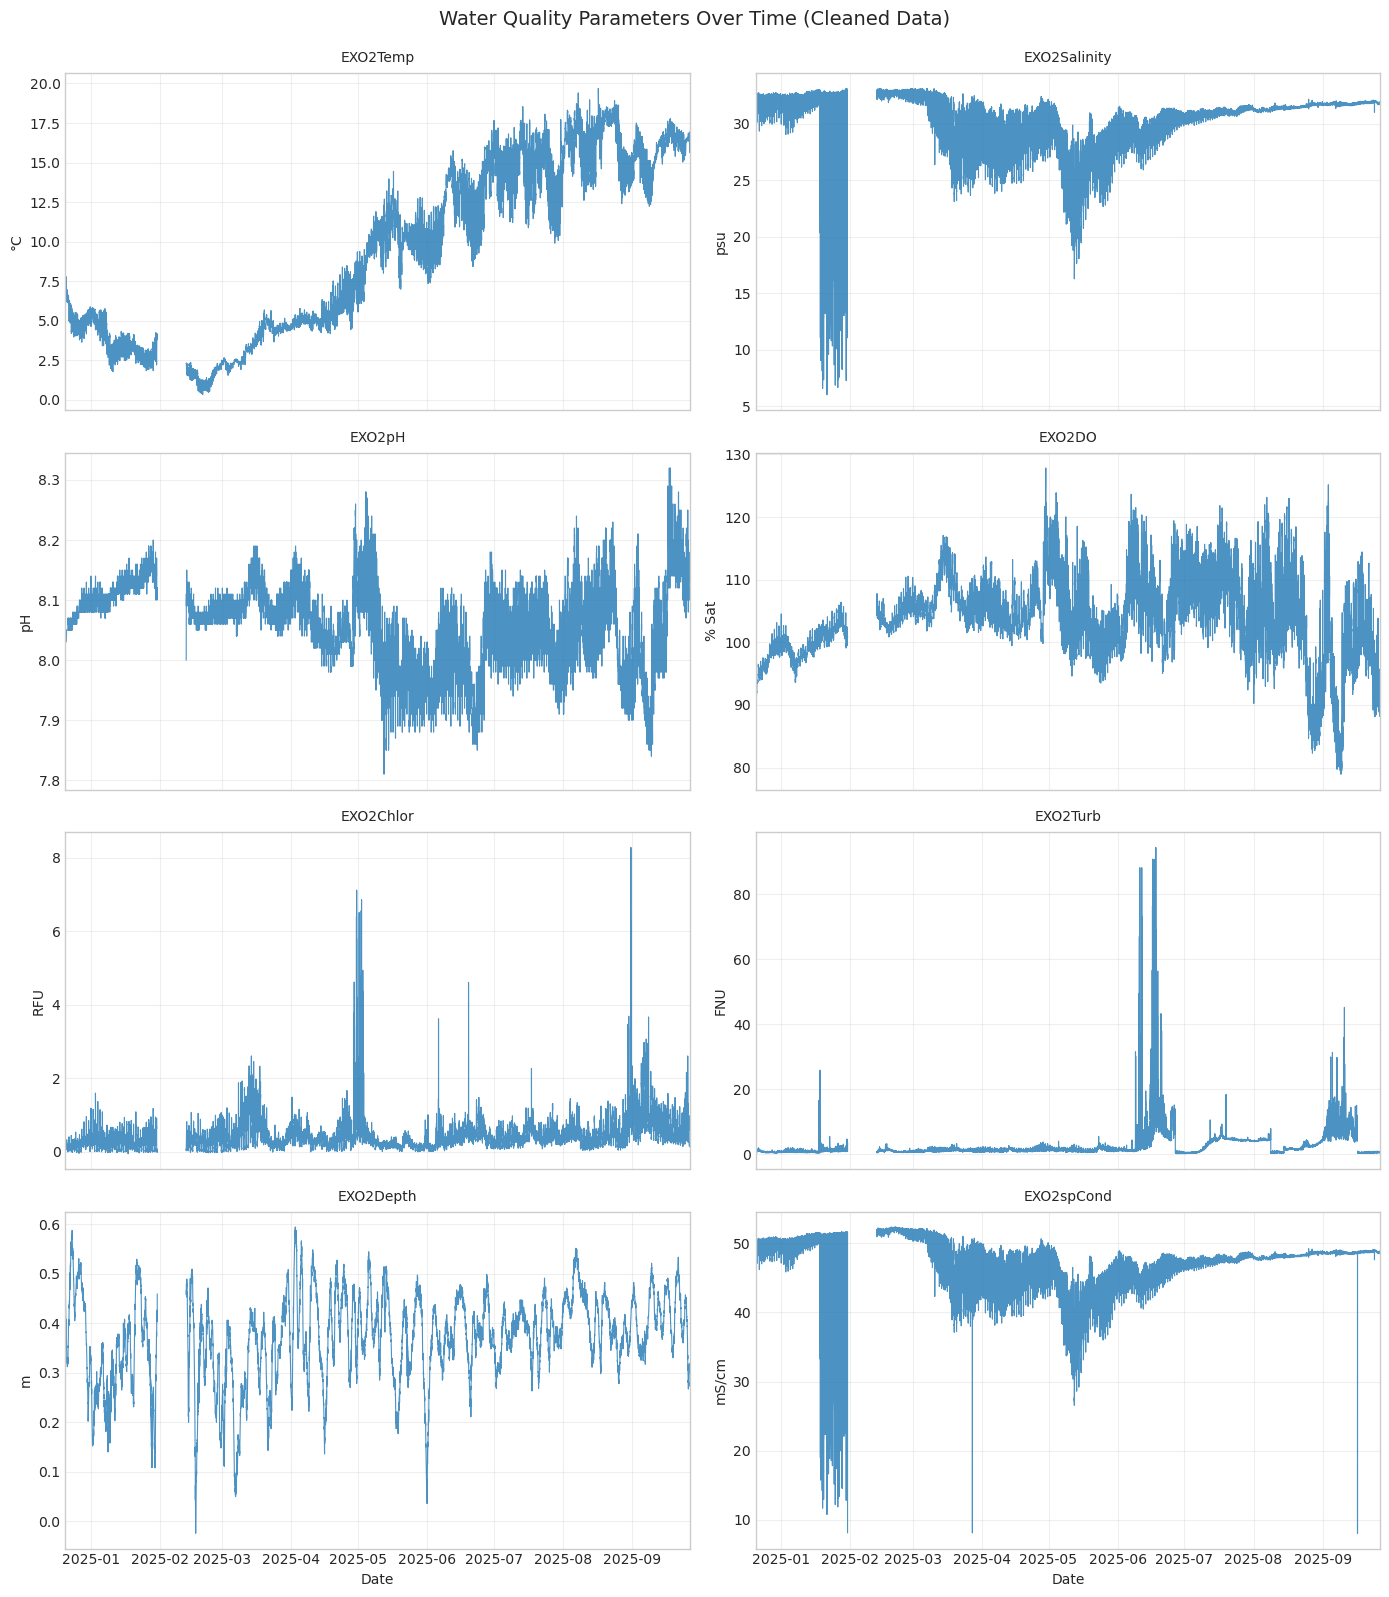

In [20]:
# Re-create time series plots with cleaned data
params = [
    ('EXO2Temp', '°C'),
    ('EXO2Salinity', 'psu'),
    ('EXO2pH', 'pH'),
    ('EXO2DO', '% Sat'),
    ('EXO2Chlor', 'RFU'),
    ('EXO2Turb', 'FNU'),
    ('EXO2Depth', 'm'),
    ('EXO2spCond', 'mS/cm')
]

fig, axes = plot_timeseries_grid(
    df=exo2_clean,
    params=params,
    timestamp_col='TIMESTAMP',
    title='Water Quality Parameters Over Time (Cleaned Data)',
    figsize=(14, 16),
    layout=(4, 2)
)
plt.show()

## 5. Correlation Analysis

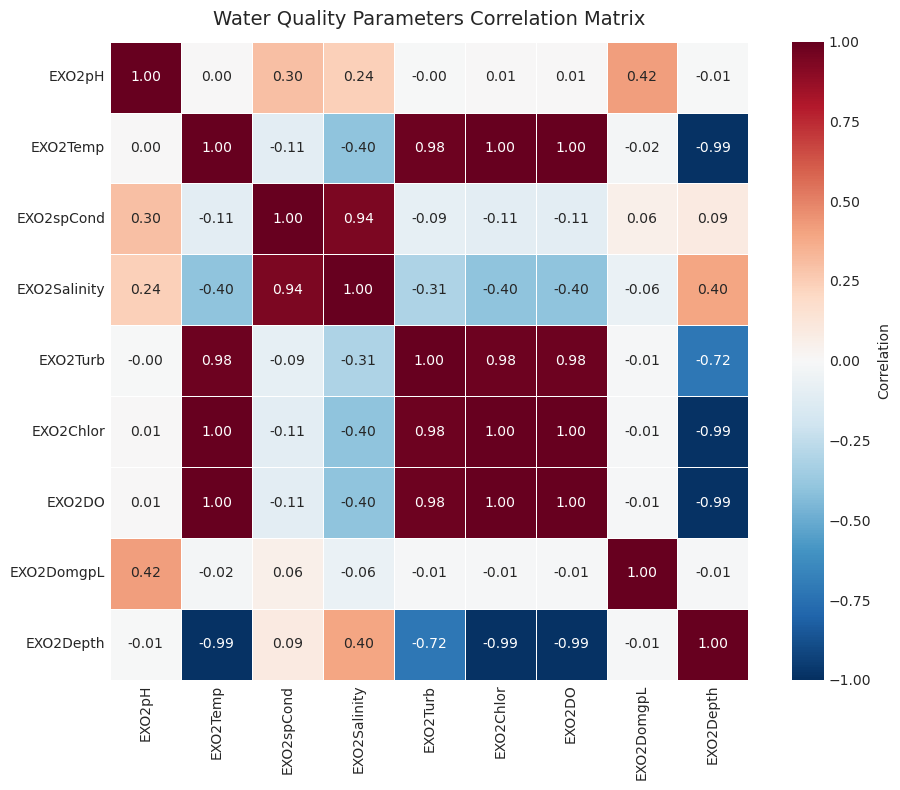

In [21]:
# Correlation matrix for water quality parameters
wq_params = ['EXO2pH', 'EXO2Temp', 'EXO2spCond', 'EXO2Salinity', 
             'EXO2Turb', 'EXO2Chlor', 'EXO2DO', 'EXO2DomgpL', 'EXO2Depth']

fig, ax, correlation_matrix = plot_correlation_heatmap(
    df=exo2_df,
    columns=wq_params,
    title='Water Quality Parameters Correlation Matrix',
    figsize=(10, 8),
    cmap='RdBu_r',
    annot=True
)
plt.show()

In [22]:
# Identify strongest correlations
corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_pairs.append({
            'Param 1': correlation_matrix.columns[i],
            'Param 2': correlation_matrix.columns[j],
            'Correlation': correlation_matrix.iloc[i, j]
        })

corr_df = pd.DataFrame(corr_pairs).sort_values('Correlation', key=abs, ascending=False)
display_info("<strong>Strongest Correlations (|r| &gt; 0.7):</strong>")
corr_df[abs(corr_df['Correlation']) > 0.7].head(10)

,Param 1,Param 2,Correlation
11,EXO2Temp,EXO2Chlor,1.000
30,EXO2Chlor,EXO2DO,1.000
12,EXO2Temp,EXO2DO,1.000
32,EXO2Chlor,EXO2Depth,-0.986
34,EXO2DO,EXO2Depth,-0.986
14,EXO2Temp,EXO2Depth,-0.986
27,EXO2Turb,EXO2DO,0.983
10,EXO2Temp,EXO2Turb,0.983
26,EXO2Turb,EXO2Chlor,0.983
15,EXO2spCond,EXO2Salinity,0.942


## 6. Distribution Analysis

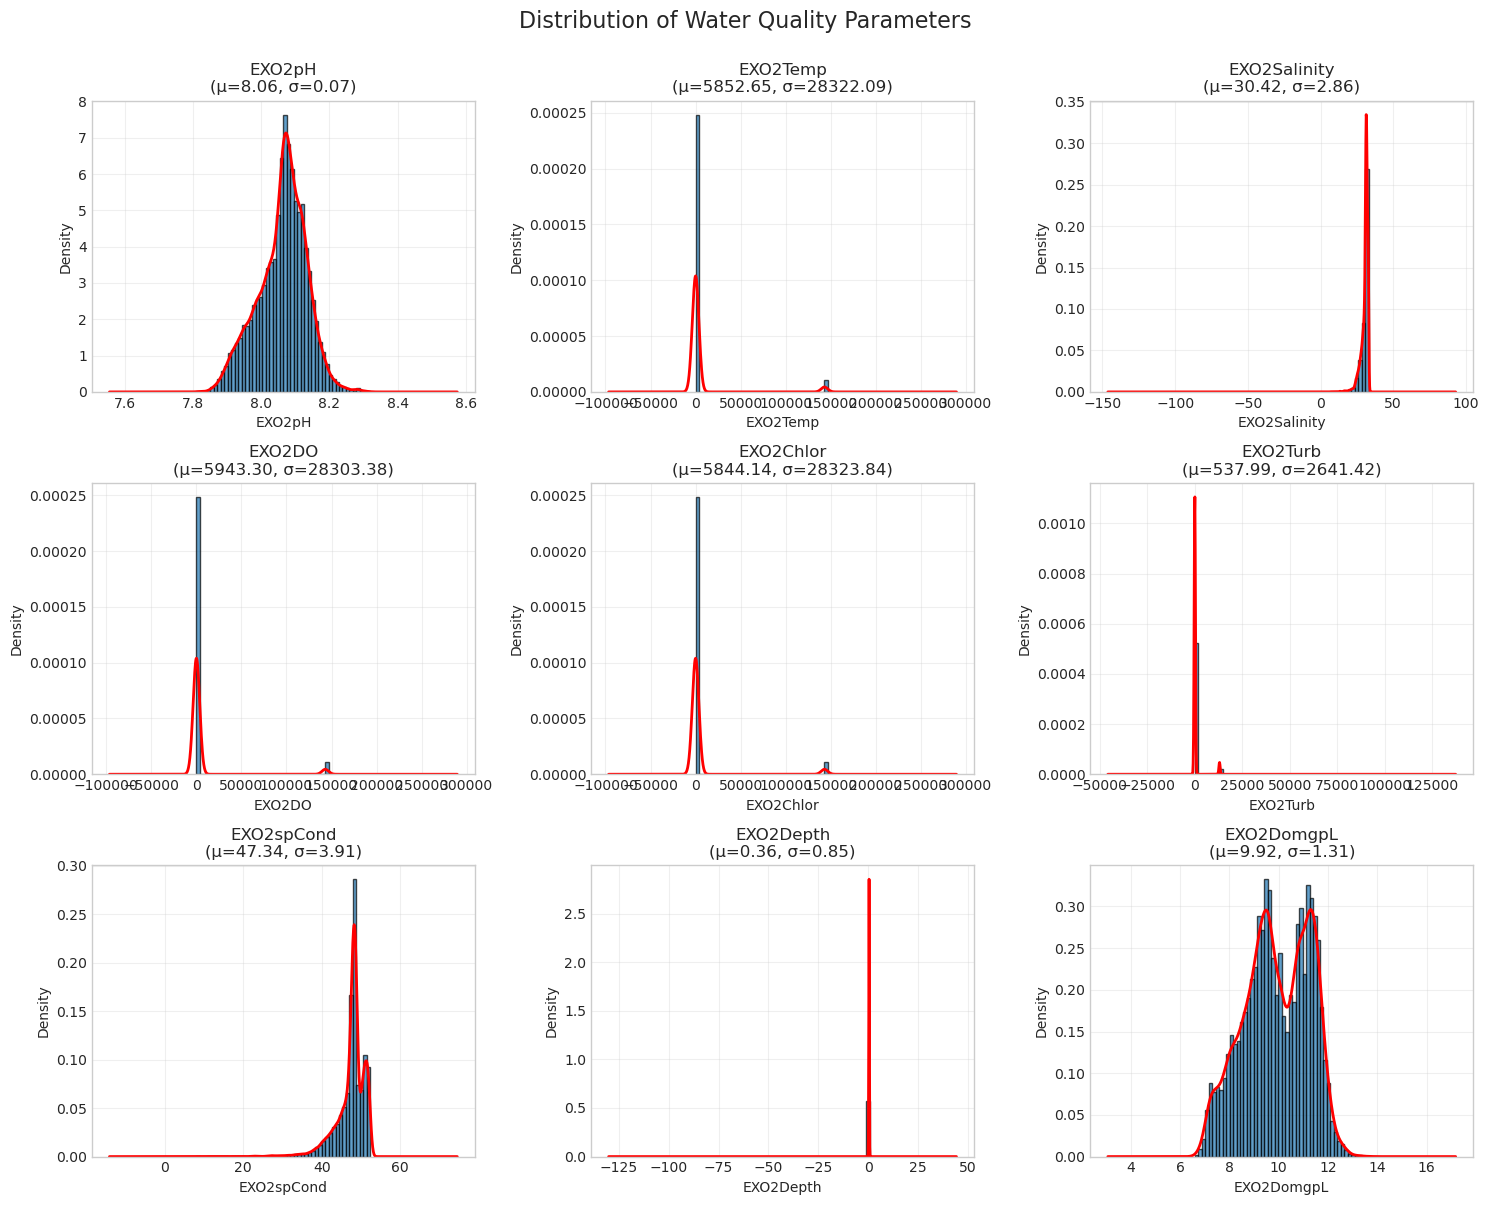

In [23]:
# Create distribution plots
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Distribution of Water Quality Parameters', fontsize=16, y=1.00)

plot_params = ['EXO2pH', 'EXO2Temp', 'EXO2Salinity', 'EXO2DO', 
               'EXO2Chlor', 'EXO2Turb', 'EXO2spCond', 'EXO2Depth', 'EXO2DomgpL']

for idx, param in enumerate(plot_params):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    # Histogram with KDE
    data = exo2_df[param].dropna()
    ax.hist(data, bins=50, alpha=0.7, edgecolor='black', density=True)
    
    # Add KDE line
    data.plot.kde(ax=ax, color='red', linewidth=2)
    
    ax.set_xlabel(param)
    ax.set_ylabel('Density')
    ax.set_title(f'{param}\n(μ={data.mean():.2f}, σ={data.std():.2f})')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Current Profile Analysis

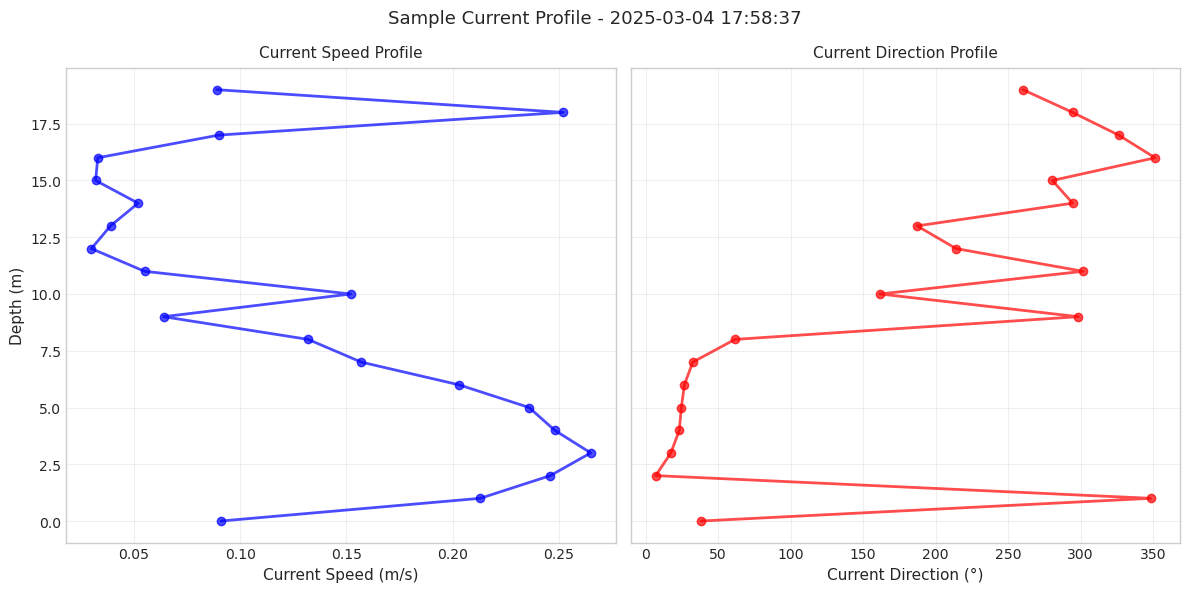

In [24]:
# Analyze a sample current profile
sample_idx = len(zcel_df) // 2  # Middle record
sample_record = zcel_df.iloc[sample_idx]

# Extract depth, speed, and direction for this record
depths = [sample_record[col] for col in depth_cols]
speeds = [sample_record[col] for col in speed_cols]
directions = [sample_record[col] for col in dir_cols]

display_info(f"""
<strong>Sample Current Profile (Record {sample_idx}):</strong><br>
<strong>Timestamp:</strong> {sample_record['TIMESTAMP']}<br>
<strong>Water Temperature:</strong> {sample_record['ZCel_WTmp']:.2f}°C<br>
<strong>Pressure:</strong> {sample_record['ZCel_Press']:.3f} dBar
""")

# Create profile plot
fig, axes = plot_current_profile(
    depths=depths,
    speeds=speeds,
    directions=directions,
    timestamp=str(sample_record['TIMESTAMP']),
    title='Sample Current Profile',
    figsize=(12, 6)
)
plt.show()

## 8. Summary Statistics and Data Quality Report

In [25]:
display_info(f"""
<strong style='font-size: 16px;'>DATA QUALITY SUMMARY REPORT</strong><br><br>

<strong>1. EXO2 WATER QUALITY DATA</strong><br>
&nbsp;&nbsp;<strong>Station:</strong> {exo2_metadata['station']}<br>
&nbsp;&nbsp;<strong>Table:</strong> {exo2_metadata['table_name']}<br>
&nbsp;&nbsp;<strong>Total Records:</strong> {len(exo2_df):,}<br>
&nbsp;&nbsp;<strong>Date Range:</strong> {exo2_df['TIMESTAMP'].min()} to {exo2_df['TIMESTAMP'].max()}<br>
&nbsp;&nbsp;<strong>Duration:</strong> {exo2_df['TIMESTAMP'].max() - exo2_df['TIMESTAMP'].min()}<br>
&nbsp;&nbsp;<strong>Sampling Interval:</strong> {exo2_df['time_diff'].mode().iloc[0]} (most common)<br>
&nbsp;&nbsp;<strong>Duplicate Timestamps:</strong> {duplicate_timestamps}<br>
&nbsp;&nbsp;<strong>Columns:</strong> {len(exo2_df.columns)}<br>
&nbsp;&nbsp;<strong>Missing Data:</strong> {exo2_df.isnull().sum().sum():,} values ({(exo2_df.isnull().sum().sum()/(len(exo2_df)*len(exo2_df.columns))*100):.2f}%)<br>
<br>
<strong>2. ZCEL CURRENT PROFILER DATA</strong><br>
&nbsp;&nbsp;<strong>Station:</strong> {zcel_metadata['station']}<br>
&nbsp;&nbsp;<strong>Table:</strong> {zcel_metadata['table_name']}<br>
&nbsp;&nbsp;<strong>Total Records:</strong> {len(zcel_df):,}<br>
&nbsp;&nbsp;<strong>Date Range:</strong> {zcel_df['TIMESTAMP'].min()} to {zcel_df['TIMESTAMP'].max()}<br>
&nbsp;&nbsp;<strong>Duration:</strong> {zcel_df['TIMESTAMP'].max() - zcel_df['TIMESTAMP'].min()}<br>
&nbsp;&nbsp;<strong>Sampling Interval:</strong> {zcel_df['time_diff'].mode().iloc[0]} (most common)<br>
&nbsp;&nbsp;<strong>Columns:</strong> {len(zcel_df.columns)}<br>
&nbsp;&nbsp;<strong>Depth Bins:</strong> {len(depth_cols)}<br>
&nbsp;&nbsp;<strong>Missing Data:</strong> {zcel_df.isnull().sum().sum():,} values ({(zcel_df.isnull().sum().sum()/(len(zcel_df)*len(zcel_df.columns))*100):.2f}%)<br>
<br>
<strong>3. KEY FINDINGS</strong><br>
&nbsp;&nbsp;• Both datasets are from the same station: {exo2_metadata['station']}<br>
&nbsp;&nbsp;• Data format: Campbell Scientific TOA5<br>
&nbsp;&nbsp;• Python modules suitable for loading: pandas (with custom TOA5 parser)<br>
&nbsp;&nbsp;• Water quality measurements: pH, temperature, salinity, DO, chlorophyll, turbidity<br>
&nbsp;&nbsp;• Current profiling: {len(depth_cols)} depth bins with speed and direction<br>
&nbsp;&nbsp;• Time alignment: Both datasets cover similar time periods
""")

## 9. Next Steps

Based on this initial exploration, recommended next steps include:

1. **Data Cleaning:**
   - Handle duplicate timestamps in EXO2 data
   - Investigate and address any anomalous values
   - Create flags for data quality issues

2. **Advanced Analysis:**
   - Diurnal/tidal patterns in water quality
   - Relationship between currents and water quality
   - Stratification analysis using temperature/salinity profiles
   - Seasonal trends (if longer time series available)

3. **Feature Engineering:**
   - Derived parameters (e.g., water density, Richardson number)
   - Tidal phase indicators
   - Current magnitude and vector components
   - See [Feature Engineering Documentation](../docs/planning/feature-engineering.md) for detailed parameter definitions

4. **Modeling Opportunities:**
   - Predictive models for dissolved oxygen
   - Water quality forecasting
   - Current pattern classification
   - Anomaly detection for aquaculture monitoring

## 10. Export Processed Data (Optional)

In [26]:
# Export cleaned data in both Feather and Parquet formats

from imta_analytics.data import convert_to_feather

output_dir = Path('../data/processed')
output_dir.mkdir(exist_ok=True)

# Export as Feather (blazing fast reads for streaming algorithms)
# Using cleaned versions: exo2_clean has quality filters applied
convert_to_feather(exo2_clean, output_dir / 'exo2_data.feather', compression='lz4')
convert_to_feather(zcel_df, output_dir / 'zcel_data.feather', compression='lz4')

# Also export as Parquet (best compression for archival)
exo2_clean.to_parquet(output_dir / 'exo2_data.parquet', compression='zstd', index=False)
zcel_df.to_parquet(output_dir / 'zcel_data.parquet', compression='zstd', index=False)

# Report file sizes
import os
exo2_feather_size = os.path.getsize(output_dir / 'exo2_data.feather') / (1024 * 1024)
exo2_parquet_size = os.path.getsize(output_dir / 'exo2_data.parquet') / (1024 * 1024)
zcel_feather_size = os.path.getsize(output_dir / 'zcel_data.feather') / (1024 * 1024)
zcel_parquet_size = os.path.getsize(output_dir / 'zcel_data.parquet') / (1024 * 1024)

display_success(f"""
✓ Data exported successfully<br><br>
<strong>EXO2 Water Quality Data (cleaned):</strong><br>
&nbsp;&nbsp;Feather: {exo2_feather_size:.2f} MB (fast reads)<br>
&nbsp;&nbsp;Parquet: {exo2_parquet_size:.2f} MB (archival)<br>
<br>
<strong>ZCell Current Profiler Data:</strong><br>
&nbsp;&nbsp;Feather: {zcel_feather_size:.2f} MB (fast reads)<br>
&nbsp;&nbsp;Parquet: {zcel_parquet_size:.2f} MB (archival)<br>
<br>
<strong>Quick reload examples:</strong><br>
<code>df = pd.read_feather('data/processed/exo2_data.feather')</code> # Fastest<br>
<code>df = pd.read_parquet('data/processed/exo2_data.parquet')</code> # Smaller
""")

In [27]:
%time df = pd.read_parquet('../data/processed/exo2_data.parquet')

CPU times: user 56.8 ms, sys: 10.6 ms, total: 67.5 ms
Wall time: 50.2 ms


In [28]:
%time df = pd.read_feather('../data/processed/exo2_data.feather')

CPU times: user 10.3 ms, sys: 0 ns, total: 10.3 ms
Wall time: 5.99 ms
